# Capítulo 8: Métricas de Error y Evaluación Predictiva

## 8.1 Métricas utilizadas

| Métrica | Fórmula | Unidad | Sensibilidad |
|---------|---------|--------|-------------|
| **MAPE** | $\frac{1}{h}\sum\left|\frac{y_t-\hat{y}_t}{y_t}\right|\times 100$ | % | Escala-independiente |
| **MAE**  | $\frac{1}{h}\sum|y_t-\hat{y}_t|$ | USD | Lineal en error |
| **RMSE** | $\sqrt{\frac{1}{h}\sum(y_t-\hat{y}_t)^2}$ | USD | Penaliza outliers |
| **MSE**  | $\frac{1}{h}\sum(y_t-\hat{y}_t)^2$ | USD² | Base de RMSE |
| **R²**   | $1 - SS_{res}/SS_{tot}$ | adim. | Varianza explicada |

## 8.2 Resultados obtenidos

### Horizonte 7 días

| Criterio | Método | MAPE (%) | MAE ($) | RMSE ($) | R² |
|----------|--------|----------|---------|----------|----|
| AIC | Rolling | 2.1873 | 1534.97 | 1818.78 | −1.5101 |
| AIC | Directo | 5.7640 | 4011.95 | 4172.88 | −12.2129 |
| BIC | Rolling | 2.1904 | 1537.64 | 1809.69 | −1.4850 |
| BIC | Directo | 5.7034 | 3969.56 | 4132.23 | −11.9567 |
| HQIC | Rolling | 2.1873 | 1534.97 | 1818.78 | −1.5101 |
| HQIC | Directo | 5.7640 | 4011.95 | 4172.88 | −12.2129 |

### Horizonte 14 días

| Criterio | Método | MAPE (%) | MAE ($) | RMSE ($) | R² |
|----------|--------|----------|---------|----------|----|
| AIC | Rolling | 1.6778 | 1194.92 | 1500.28 | 0.2917 |
| AIC | Directo | 2.2223 | 1602.65 | 2122.03 | −0.4171 |
| BIC | Rolling | **1.6681** | **1188.31** | 1488.62 | **0.3026** |
| BIC | Directo | 2.1563 | 1555.05 | 2085.28 | −0.3684 |
| HQIC | Rolling | 1.6778 | 1194.92 | 1500.28 | 0.2917 |
| HQIC | Directo | 2.2223 | 1602.65 | 2122.03 | −0.4171 |

### Horizonte 21 días

| Criterio | Método | MAPE (%) | MAE ($) | RMSE ($) | R² |
|----------|--------|----------|---------|----------|----|
| AIC | Rolling | 2.1442 | 1511.75 | 1853.29 | 0.2319 |
| AIC | Directo | 3.4223 | 2448.93 | 2974.01 | −0.9779 |
| BIC | Rolling | 2.1444 | 1511.95 | 1852.00 | 0.2330 |
| BIC | Directo | 3.4025 | 2434.26 | 2950.84 | −0.9471 |
| HQIC | Rolling | **2.1575** | 1520.41 | 1858.06 | 0.2280 |
| HQIC | Directo | 3.3837 | 2420.62 | 2935.49 | −0.9270 |

### Horizonte 28 días

| Criterio | Método | MAPE (%) | MAE ($) | RMSE ($) | R² |
|----------|--------|----------|---------|----------|----|
| AIC | Rolling | **2.2180** | **1545.42** | 1904.37 | **0.3274** |
| AIC | Directo | 7.7804 | 5485.18 | 5956.44 | −5.5802 |
| BIC | Rolling | 2.2349 | 1557.19 | 1909.51 | 0.3238 |
| BIC | Directo | 7.8142 | 5508.68 | 5978.07 | −5.6280 |
| HQIC | Rolling | 2.2180 | 1545.42 | 1904.37 | 0.3274 |
| HQIC | Directo | 7.7804 | 5485.18 | 5956.44 | −5.5802 |


## 8.3 Análisis de resultados

### Rolling vs Directo — Factor de degradación

| Horizonte | MAPE Rolling | MAPE Directo | Factor |
|-----------|-------------|-------------|--------|
| 7d  | 2.19% | 5.70% | ×2.61 |
| 14d | 1.67% | 2.16% | ×1.29 |
| 21d | 2.14% | 3.38% | ×1.58 |
| 28d | 2.22% | 7.78% | ×3.51 |

### R² negativo — interpretación

$$R^2 < 0 \iff SS_{res} > SS_{tot} \iff \sum(y_t - \hat{y}_t)^2 > \sum(y_t - \bar{y})^2$$

El modelo directo es **peor predictor que la media histórica**. Para el horizonte 7d directo con $R^2 = -12.21$, el modelo produce errores cuadráticos ~13 veces mayores que la varianza total — consecuencia directa de que ARIMA(1,1,0) converge a la media incondicional sin actualización de la historia reciente.

:::{admonition} Resultado destacado
:class: important
El rolling con horizonte 14d y criterio BIC produce el menor MAPE global: **1.6681%** con $R^2 = 0.3026$. Sin embargo, dado que la diferencia entre criterios es inferior a 0.01%, la elección del criterio es estadísticamente irrelevante para esta serie. La variable decisiva es el **método de predicción**: rolling supera al directo en todos los casos.
:::

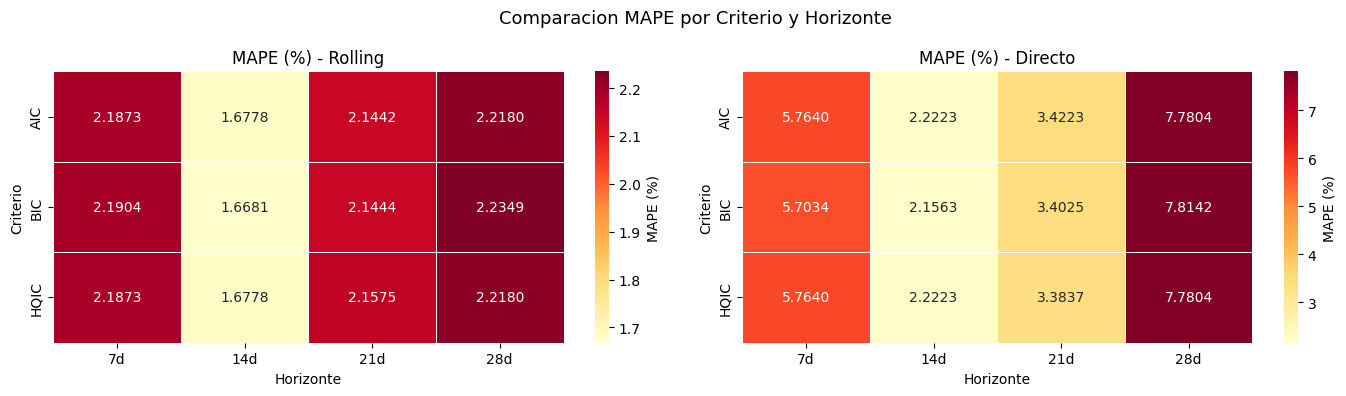

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Heatmap MAPE rolling
criterios  = ['AIC', 'BIC', 'HQIC']
horizontes = ['7d', '14d', '21d', '28d']

mape_rolling = np.array([
    [2.1873, 1.6778, 2.1442, 2.2180],  # AIC
    [2.1904, 1.6681, 2.1444, 2.2349],  # BIC
    [2.1873, 1.6778, 2.1575, 2.2180],  # HQIC
])

mape_directo = np.array([
    [5.7640, 2.2223, 3.4223, 7.7804],
    [5.7034, 2.1563, 3.4025, 7.8142],
    [5.7640, 2.2223, 3.3837, 7.7804],
])

import pandas as pd
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title in zip(axes,
    [mape_rolling, mape_directo],
    ['MAPE (%) - Rolling', 'MAPE (%) - Directo']):
    df = pd.DataFrame(data, index=criterios, columns=horizontes)
    sns.heatmap(df, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'MAPE (%)'})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Horizonte')
    ax.set_ylabel('Criterio')

plt.suptitle('Comparacion MAPE por Criterio y Horizonte', fontsize=13)
plt.tight_layout()
plt.savefig('fig_heatmap_mape.png', dpi=150, bbox_inches='tight')
plt.show()

:::{admonition} Conclusión — Capítulo 8
:class: tip

1. **Rolling domina al directo** en todos los horizontes y criterios sin excepción. La actualización diaria del modelo es indispensable para predicción operacional.

2. **R² negativo en forecast directo** confirma que el modelo estático es inferior a la media histórica como predictor — resultado esperado para procesos I(1) sin actualización.

3. **Diferencia entre criterios AIC/BIC/HQIC es marginal** ($\Delta$MAPE < 0.01%) — los tres criterios producen modelos de performance equivalente para BTC.

4. **Mejor configuración observada:** Rolling + BIC + 14 días (MAPE = 1.6681%, $R^2$ = 0.3026).

5. **Limitación estructural:** El $R^2$ máximo de ~0.30 indica que ARIMA captura solo el 30% de la varianza en el mejor caso. La varianza residual refleja heterocedasticidad condicional no modelada (efecto ARCH/GARCH).
:::